In [28]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [29]:
df = pd.read_csv("../data/ESC-50-master/ESC-50-master/meta/esc50.csv")

In [30]:
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [31]:
df.shape

(2000, 7)

In [32]:
df.columns.to_list()

['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']

In [33]:
df['fold'].unique()

array([1, 2, 3, 4, 5])

In [34]:
df['target'].unique()

array([ 0, 14, 36, 19, 30, 34,  9, 22, 48, 41, 47, 31, 17, 45,  8, 15, 46,
       37, 32, 16, 25,  4,  3, 27, 43, 12, 40, 29, 10,  7, 26,  6, 44, 23,
       20, 49, 24, 39, 28, 18,  2, 35, 38, 21,  1, 11, 42,  5, 33, 13])

In [35]:
df['category'].unique()

array(['dog', 'chirping_birds', 'vacuum_cleaner', 'thunderstorm',
       'door_wood_knock', 'can_opening', 'crow', 'clapping', 'fireworks',
       'chainsaw', 'airplane', 'mouse_click', 'pouring_water', 'train',
       'sheep', 'water_drops', 'church_bells', 'clock_alarm',
       'keyboard_typing', 'wind', 'footsteps', 'frog', 'cow',
       'brushing_teeth', 'car_horn', 'crackling_fire', 'helicopter',
       'drinking_sipping', 'rain', 'insects', 'laughing', 'hen', 'engine',
       'breathing', 'crying_baby', 'hand_saw', 'coughing',
       'glass_breaking', 'snoring', 'toilet_flush', 'pig',
       'washing_machine', 'clock_tick', 'sneezing', 'rooster',
       'sea_waves', 'siren', 'cat', 'door_wood_creaks', 'crickets'],
      dtype=object)

In [36]:
df['category'].value_counts()

category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring             40
toilet_flush        40
pig                 40
washing_machine     40
clock_tick          40
sn

In [37]:
sample = df.iloc[0]
audio_pth = f'../data/ESC-50-master/ESC-50-master/audio/{sample["filename"]}'

y, sr = librosa.load(audio_pth, sr=None)

print(f'Category: {sample["category"]}')
print(f'Sample rate: {sr}')
print(f'Duration: {len(y)/sr:.2f} seconds')
print(f'Shape: {y.shape}')

Category: dog
Sample rate: 44100
Duration: 5.00 seconds
Shape: (220500,)


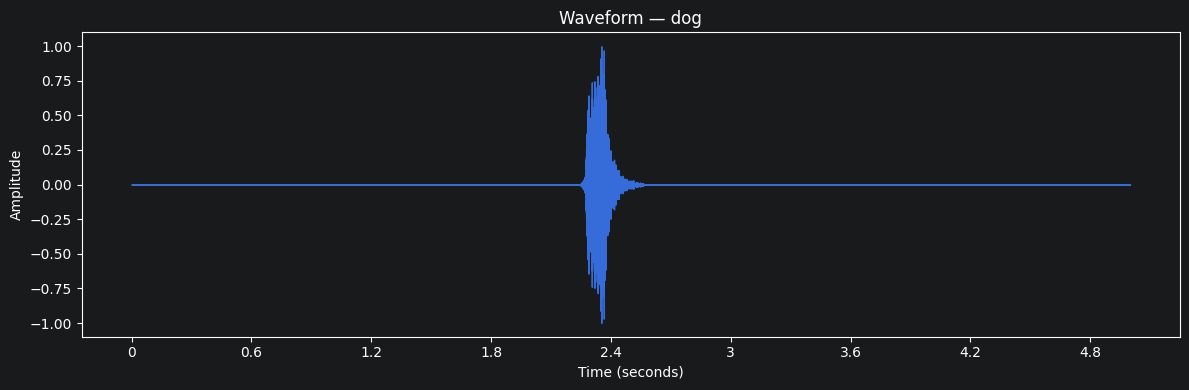

In [38]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Waveform — {sample["category"]}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [39]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

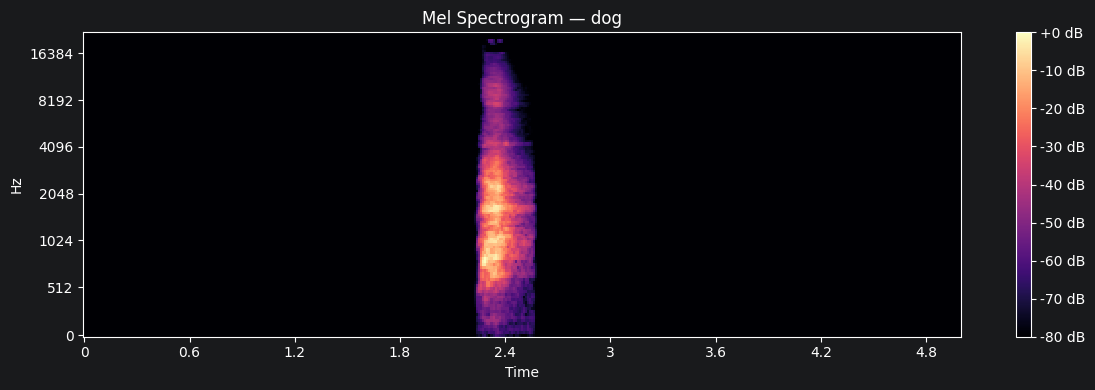

In [40]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel Spectrogram — {sample["category"]}')
plt.tight_layout()
plt.show()

In [41]:
sample = df.iloc[10]
audio_pth = f'../data/ESC-50-master/ESC-50-master/audio/{sample["filename"]}'

y, sr = librosa.load(audio_pth, sr=None)

print(f'Category: {sample["category"]}')
print(f'Sample rate: {sr}')
print(f'Duration: {len(y)/sr:.2f} seconds')
print(f'Shape: {y.shape}')

Category: door_wood_knock
Sample rate: 44100
Duration: 5.00 seconds
Shape: (220500,)


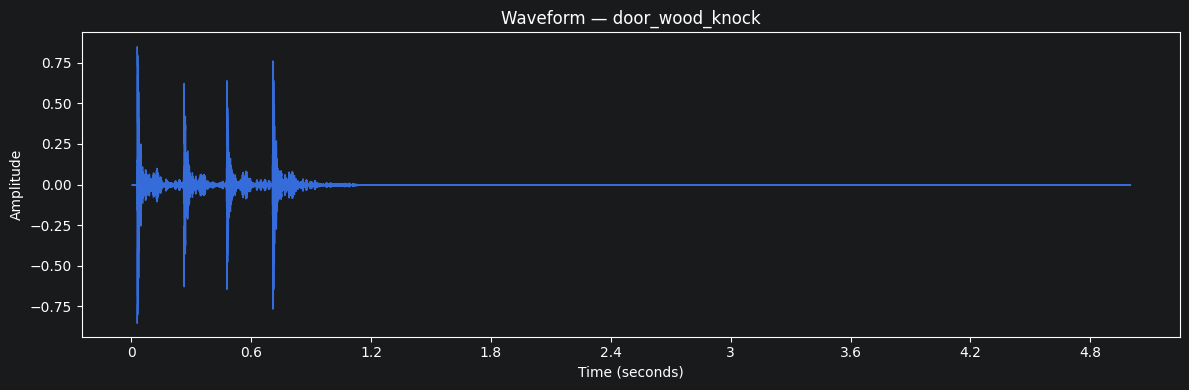

In [42]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Waveform — {sample["category"]}')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [43]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

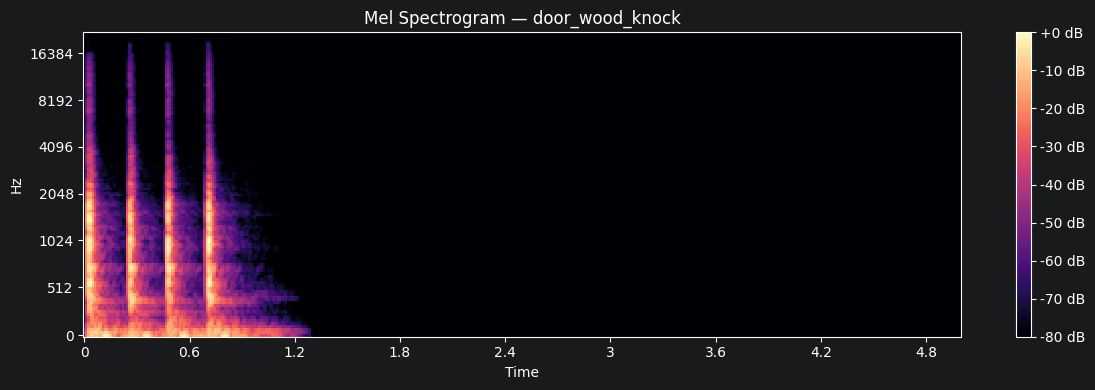

In [44]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel Spectrogram — {sample["category"]}')
plt.tight_layout()
plt.show()

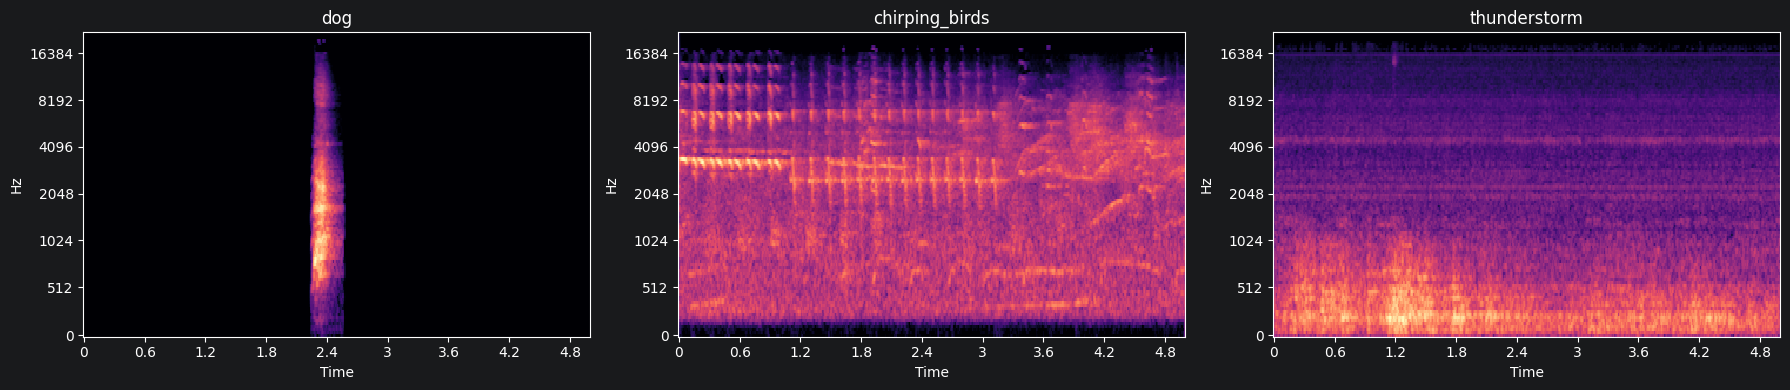

In [46]:
categories_to_compare = ['dog', 'chirping_birds', 'thunderstorm']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, cat in enumerate(categories_to_compare):
    row = df[df['category'] == cat].iloc[0]
    path = f'../data/ESC-50-master/ESC-50-master/audio/{row["filename"]}'
    y_tmp, sr_tmp = librosa.load(path, sr=None)
    S = librosa.feature.melspectrogram(y=y_tmp, sr=sr_tmp, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.sca(axes[i])
    librosa.display.specshow(S_db, sr=sr_tmp, x_axis='time', y_axis='mel')
    axes[i].set_title(cat)

plt.tight_layout()
plt.show()

In [47]:
audio_folder = '../data/ESC-50-master/ESC-50-master/audio/'
files = os.listdir(audio_folder)
print(files[:5])

['1-100032-A-0.wav', '1-100038-A-14.wav', '1-100210-A-36.wav', '1-100210-B-36.wav', '1-101296-A-19.wav']
